# Numpy

The most used Python library, with C++ backend.
Numpy arrays are better in storage efficiency, they can modify elements inplace, instead of python lists which are always dynamically allocated.

In [39]:
# In collab doesn't work, but locally it should

!python -m venv ml_env # creates an environment

!source ml_env/bin/activate # activates the env
!deactivate # deactivates the env

UsageError: Line magic function `%python` not found (But cell magic `%%python` exists, did you mean that instead?).


In [ ]:
!pip install numpy

In [ ]:
import numpy as np

In [ ]:
# 1D
arr = np.array([1, 2, 3, 4])

print("array:", arr)
print("array type:", type(arr))
print("elements type:", arr.dtype)
print("layout:", arr.shape)
print("one element:", arr[0])

array: [1 2 3 4]
array type: <class 'numpy.ndarray'>
elements type: int64
layout: (4,)
one element: 1


In [ ]:
# slicing [a:b:s] -> math interval [a, b) with step s

print("first 2 elements:", arr[:2])
print("last element:", arr[-1])
print("custom range", arr[1:3])
print("odd position elements", arr[1::2])

first 2 elements: [1 2]
last element: 4
custom range [2 3]
odd position elements [2 4]


In [ ]:
# 2D
mat = np.array([[1, 2, 3], [4, 5, 6]])

print("matrix shape:", mat.shape)
print("one element:", mat[0, 1])
print("one line:", mat[0, :])
print("one column:", mat[:, 0])

matrix shape: (2, 3)
one element: 2
one line: [1 2 3]
one column: [1 4]


In [ ]:
# masking
mask = mat >= 3
print("mask:", mask)

selected = mat[mask]
print(selected)
print(selected.shape)

mask: [[False False  True]
 [ True  True  True]]
[3 4 5 6]
(4,)


In [ ]:
# The easiest and most usual way to create an array
print(np.zeros((3, 2)))
print(np.ones((2, 3)))

[[0. 0.]
 [0. 0.]
 [0. 0.]]
[[1. 1. 1.]
 [1. 1. 1.]]


In [ ]:
# broadcasting
mat = np.zeros((3, 3))
vec = np.ones((3, 1))
x = 5

print(mat + vec) # vector repeats along the incomplete axis
print(mat + x)   # value repeats for all matrix element
print(mat + vec + x)

[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
[[5. 5. 5.]
 [5. 5. 5.]
 [5. 5. 5.]]
[[6. 6. 6.]
 [6. 6. 6.]
 [6. 6. 6.]]


In [ ]:
# mat functions
mat = np.zeros((3, 3)) + 3
vec = np.ones((1, 3))

print("log: ", np.log(mat))
print("dot product: ", np.matmul(vec, vec.T))         # (1, 3) x (3, 1) = (1, 1)
print("matrix multiplication: ", np.matmul(vec, mat)) # (1, 3) x (3, 3) = (1, 3)

log:  [[1.09861229 1.09861229 1.09861229]
 [1.09861229 1.09861229 1.09861229]
 [1.09861229 1.09861229 1.09861229]]
dot product:  [[3.]]
matrix multiplication:  [[9. 9. 9.]]


In [ ]:
# reshaping
arr = np.array([1, 2, 3, 4])

print(arr.reshape((2, 2)))
print(arr.reshape((2, 2, 1)))

[[1 2]
 [3 4]]
[[[1]
  [2]]

 [[3]
  [4]]]


In [ ]:
# dimension-based operators

square = arr.reshape((2, 2))
print("sum of all elements:", square.sum())
print("sum of lines:", square.sum(axis=1))
print("sum of columns:", square.sum(axis=0))

# We want the axis n to dissapear
# so we sum accross axis=n

sum of all elements: 10
sum of lines: [3 7]
sum of columns: [4 6]


In [ ]:
# argmax = index of the maximum element
# argmin = index of the minimum element

print(np.argmin(square, axis=0))
print(np.argmax(square, axis=1))

[0 0]
[1 1]


In [ ]:
# stacking
arr = np.array([1, 2, 3, 4]) # (4, )

collection = np.vstack([arr, arr, arr])
print("Vertical stacking, axis = 0:", collection.shape)

collection = np.hstack([arr, arr, arr])
print("Horizontal stacking, axis = current:", collection.shape)

collection = np.dstack([arr, arr, arr])
print("Deep stacking, axis = 2:", collection.shape)

collection = np.stack([arr, arr, arr], axis=1)
print("General stacking, axis = 1:", collection.shape)

Vertical stacking, axis = 0: (3, 4)
Horizontal stacking, axis = current: (12,)
Deep stacking, axis = 2: (1, 4, 3)
General stacking, axis = 1: (4, 3)


In [ ]:
# pdb debugging in scripts
import pdb


arr = np.array([1, 2, 3, 4]).reshape(4, 1)
# pdb.set_trace()
# Keys: c (continue), n (next instruction - step in), l (show the line where I am), exit

arr + np.zeros(8).reshape(4, 2)

array([[1., 1.],
       [2., 2.],
       [3., 3.],
       [4., 4.]])

In [ ]:
np.zeros((8,))

array([0., 0., 0., 0., 0., 0., 0., 0.])

# Pandas

Nice library for datasets manipulation and easier than SQL.

In [ ]:
import pandas as pd

In [ ]:
# Exercises recordings
!wget https://www.w3schools.com/python/pandas/data.csv

--2026-09-30 12:56:00--  https://www.w3schools.com/python/pandas/data.csv
Resolving www.w3schools.com (www.w3schools.com)... 23.33.85.243, 23.33.85.238, 2600:1407:3c00:2e::17c8:9cd6, ...
Connecting to www.w3schools.com (www.w3schools.com)|23.33.85.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2858 (2.8K) [application/octet-stream]
Saving to: ‘data.csv’

data.csv            100%[===================>]   2.79K  --.-KB/s    in 0s      

2026-09-30 12:56:00 (42.1 MB/s) - ‘data.csv’ saved [2858/2858]



In [ ]:
df = pd.read_csv("data.csv")
df.head()

,Duration,Pulse,Maxpulse,Calories
0,60,110,130,409.1
1,60,117,145,479.0
2,60,103,135,340.0
3,45,109,175,282.4
4,45,117,148,406.0


In [ ]:
mask = df["Duration"] == 60
mask

,Duration
0,True
1,True
2,True
3,False
4,False
...,...
164,True
165,True
166,True
167,False


In [ ]:
# select Maxpulse from table where Duration = 60;
select = df.loc[mask, "Maxpulse"]
select

,Maxpulse
0,130
1,145
2,135
5,127
6,136
...,...
157,120
158,150
164,140
165,145


In [ ]:
select.to_csv("edited", index=False)

In [ ]:
print(type(select))
print(type(select.values))
print(type(select.tolist()))

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
<class 'list'>


# Matplotlib

Standard library for fas ploting. Visualization is crucial in data mining,understanding, etc.

In [ ]:
import matplotlib.pyplot as plt

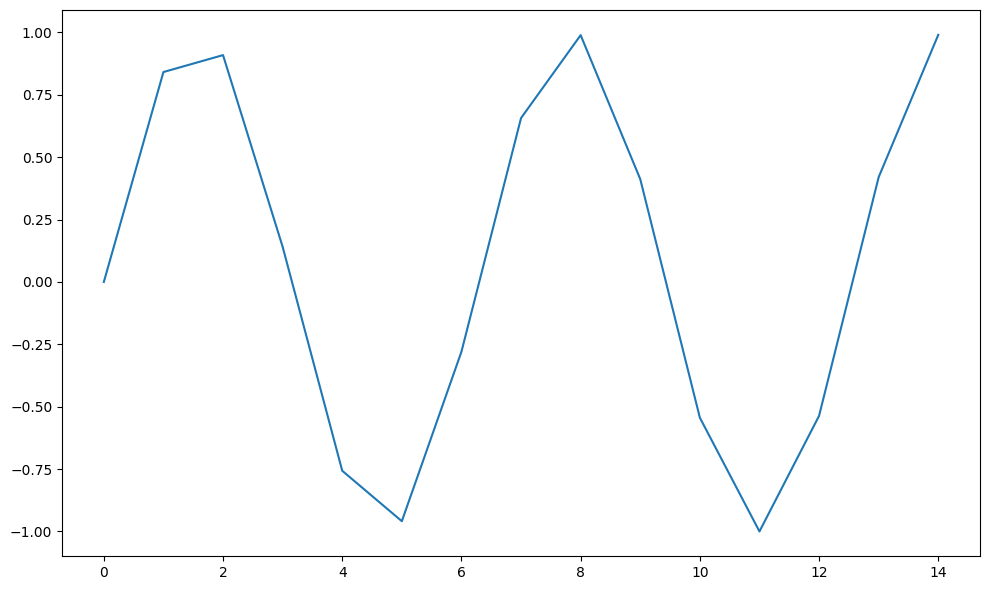

In [ ]:
# plot sin function with few values
x = np.arange(0, 15)
y = np.sin(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.tight_layout()

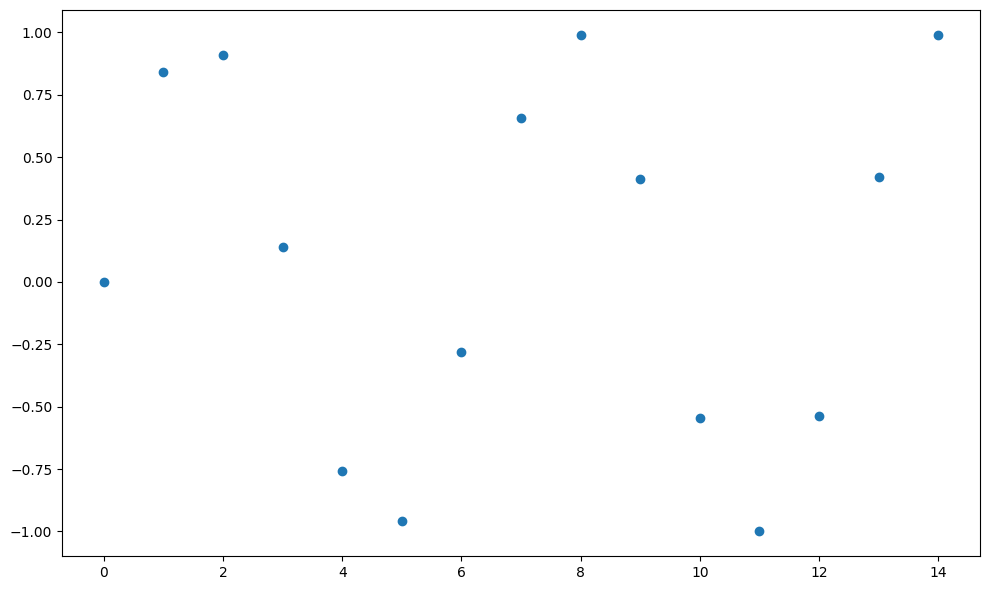

In [ ]:
# scatter

plt.figure(figsize=(10, 6))
plt.scatter(x, y, marker="o")
plt.tight_layout()

100 values in the interval [0, 15) [ 0.          0.15151515  0.3030303   0.45454545  0.60606061  0.75757576
  0.90909091  1.06060606  1.21212121  1.36363636  1.51515152  1.66666667
  1.81818182  1.96969697  2.12121212  2.27272727  2.42424242  2.57575758
  2.72727273  2.87878788  3.03030303  3.18181818  3.33333333  3.48484848
  3.63636364  3.78787879  3.93939394  4.09090909  4.24242424  4.39393939
  4.54545455  4.6969697   4.84848485  5.          5.15151515  5.3030303
  5.45454545  5.60606061  5.75757576  5.90909091  6.06060606  6.21212121
  6.36363636  6.51515152  6.66666667  6.81818182  6.96969697  7.12121212
  7.27272727  7.42424242  7.57575758  7.72727273  7.87878788  8.03030303
  8.18181818  8.33333333  8.48484848  8.63636364  8.78787879  8.93939394
  9.09090909  9.24242424  9.39393939  9.54545455  9.6969697   9.84848485
 10.         10.15151515 10.3030303  10.45454545 10.60606061 10.75757576
 10.90909091 11.06060606 11.21212121 11.36363636 11.51515152 11.66666667
 11.81818182 11.9

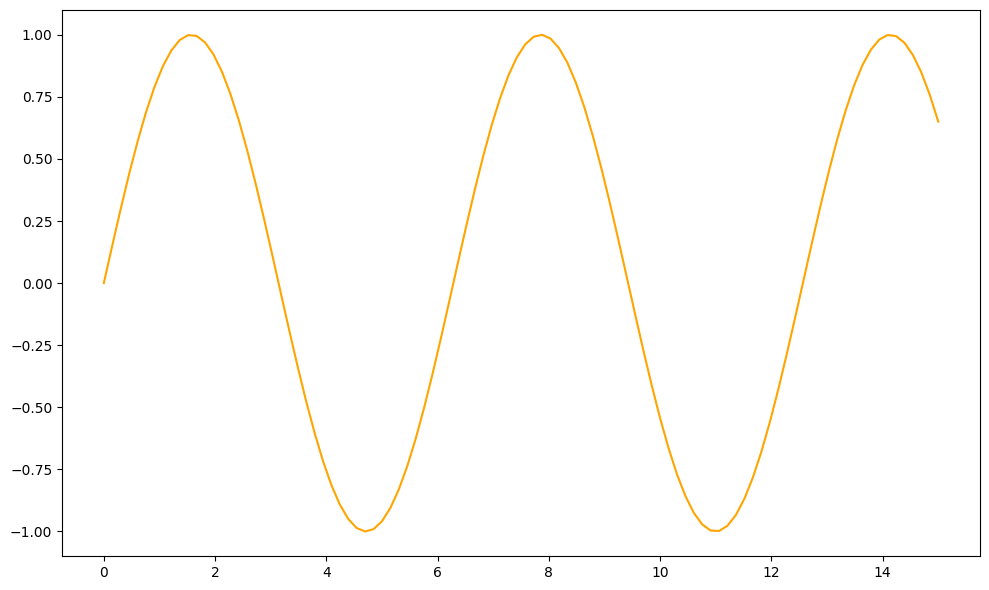

In [ ]:
x = np.linspace(0, 15, 100)
y = np.sin(x)

print("100 values in the interval [0, 15)", x)
plt.figure(figsize=(10, 6))
plt.plot(x, y, color="orange")
plt.tight_layout()


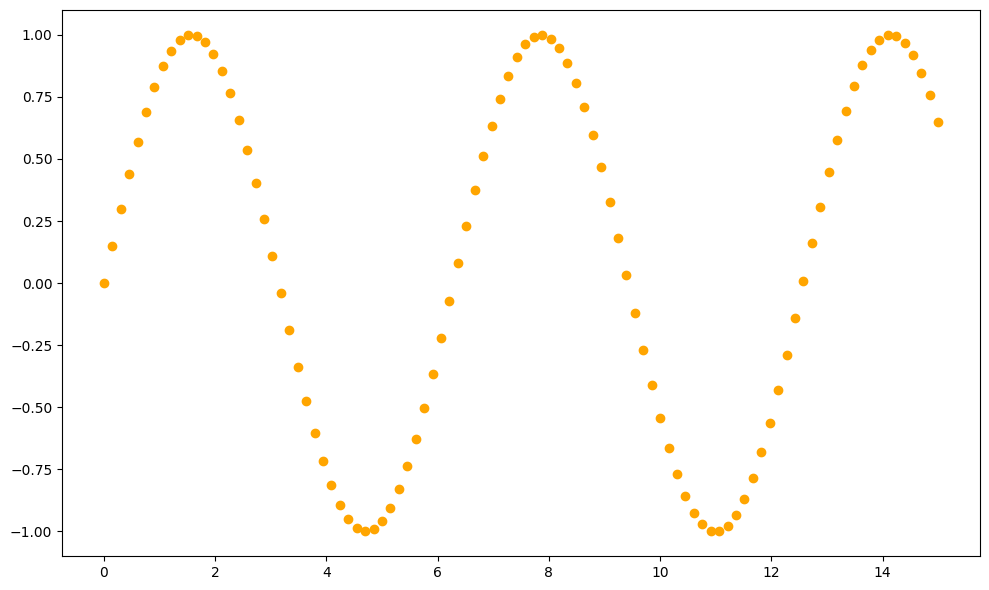

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, marker='o', color="orange")
plt.tight_layout()

(array([14., 50., 68., 14.,  4.,  1.,  5.,  2.,  2.,  0.,  1.,  0.,  1.,
         1.,  1.]),
 array([  50.3       ,  170.97333333,  291.64666667,  412.32      ,
         532.99333333,  653.66666667,  774.34      ,  895.01333333,
        1015.68666667, 1136.36      , 1257.03333333, 1377.70666667,
        1498.38      , 1619.05333333, 1739.72666667, 1860.4       ]),
 <BarContainer object of 15 artists>)

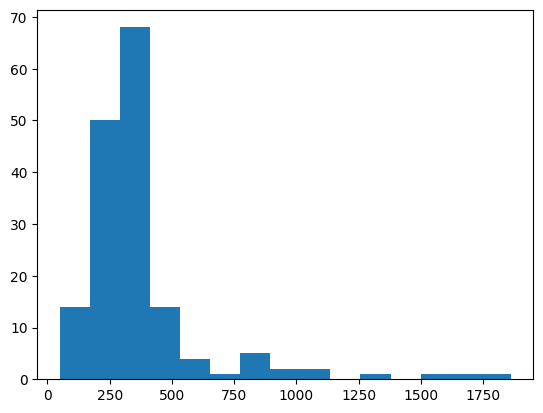

In [ ]:
calories = df["Calories"].values
plt.hist(calories, bins=15)

Answer: The Recodex ID is in the url of the user profile:

When you enter on the Recodex > Settings: the url is
https://recodex.mff.cuni.cz/app/user/****************************/edit

More instructions are on Piazza :D